In [4]:
from pathlib import Path
import matplotlib.pyplot as plt


experiment_path = Path('../rapid-geostrophic-reconstruction/figs/')

experiment_10d = 'experiment_20250106_115949'
experiment_30d = 'experiment_20250106_114727'
experiment_90d = 'experiment_20250106_121406'



In [11]:


def read_improvement(experiment_name):

    with open(experiment_path / experiment_name / 'improvement_results.json', 'r') as f:
        improvement = eval(f.read())

    

    return improvement



results_10d = read_improvement(experiment_10d)
results_30d = read_improvement(experiment_30d)
results_90d = read_improvement(experiment_90d)

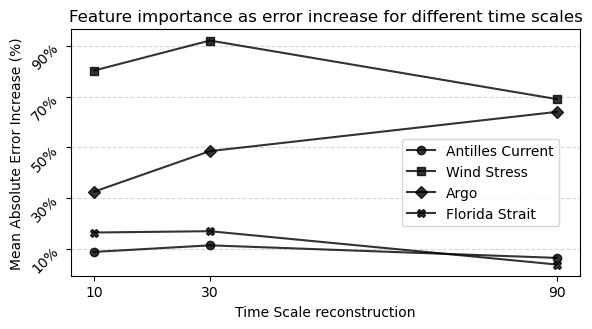

In [53]:
markers = {
    'without_ac': 'o', 
    'without_ws': 's', 
    'without_argo': 'D', 
    'without_fc': 'X'
}

names = {
    'without_ac': 'Antilles Current', 
    'without_ws': 'Wind Stress', 
    'without_argo': 'Argo', 
    'without_fc': 'Florida Strait'
}


fig = plt.figure(figsize=(6,3.4))
ax = fig.add_subplot(1,1,1)


for variable in ['without_ac', 'without_ws', 'without_argo', 'without_fc']:

    improvement_10d_var = results_10d[variable]['mae_mean'] / results_10d['original']['mae'] - 1
    improvement_30d_var = results_30d[variable]['mae_mean'] / results_30d['original']['mae'] - 1
    improvement_90d_var = results_90d[variable]['mae_mean'] / results_90d['original']['mae'] - 1


    ax.plot([10, 30, 90], [improvement_10d_var, improvement_30d_var, improvement_90d_var], label=names[variable], marker=markers[variable], c = 'black', alpha=0.8)

ax.set_xticks([10, 30, 90])

ax.set_ylabel('Mean Absolute Error Increase (%)')
ax.set_xlabel('Time Scale reconstruction')

ax.set_yticks([.1,.3,.5,.7,.9])
ax.set_yticklabels(['10%', '30%', '50%', '70%', '90%'], rotation=45)

ax.grid(which='major', axis = 'y', linestyle='--', alpha=0.5)

ax.legend(loc=(.65,.2))

ax.set_title('Feature importance as error increase for different time scales')

fig.tight_layout()


plt.savefig('../rapid-geostrophic-reconstruction/figs/feature_importance_time_scale.png', dpi=300)